# Dataset

Utilizamos el dataset MNIST que consta de numeros de 0 al 9 escritos a mano representados en imagenes de 28x28 px y su etiqueta. El dataset viene incluido en la libreria `tensorflow`.

Debido a que entrenar la red con PSO o algoritmos geneticos es un proceso lento, decidimos utilizar unicamente 1000 datapoints.


A continuacion se puede ver como lucen las imagenes

In [9]:
import collections
import tensorflow as tf
import numpy as np

data = tf.keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = data

sample_size = 1000
random_idx = np.random.randint(0, len(y_train), sample_size)

x_train, y_train = x_train[random_idx], y_train[random_idx]

data = (x_train, y_train), (x_test, y_test)
print("Ocurrences of each class in the trainning dataset: ")
print(collections.Counter(y_train))  
print()

print("Ocurrences of each class in the test dataset: ")
print(collections.Counter(y_test))  

Ocurrences of each class in the trainning dataset: 
Counter({0: 109, 3: 105, 7: 104, 6: 103, 9: 103, 2: 101, 1: 99, 5: 94, 4: 94, 8: 88})

Ocurrences of each class in the test dataset: 
Counter({1: 1135, 2: 1032, 7: 1028, 3: 1010, 9: 1009, 4: 982, 0: 980, 8: 974, 6: 958, 5: 892})


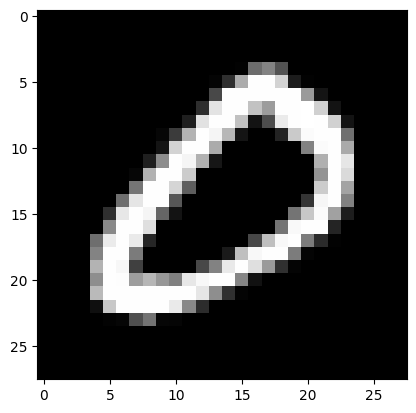

El numero en la imagen es:  0


In [11]:
from matplotlib import pyplot as plt

def show_digit(img):
    img = np.array(img, dtype='float')
    pixels = img.reshape((28, 28))
    plt.imshow(pixels, cmap='gray')
    plt.show()
show_digit(x_train[0])
print("El numero en la imagen es: ", y_train[0])

# Red neuronal

La red neuronal que utilizamos es una red neuronal fully-connected que consta de:
- Una capa de entrada de 784 elementos
- Una capa de intermedia con 128 neuronas y con activacion `relu`
- Una capa de intermedia con 64 neuronas y con activacion `relu`
- La capa de salia consta de 10 neuronas con activacion `softmax`

Para codificarla utilizamos la libreria `tensorflow`

```python
inputs = Input(shape=(784,))
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x) 
```

El comportamiento de la red neuronal se encuentra encapsulado en `model.NNModel`. Esta clase se 
inicializa con pesos aleatorios y tiene metodos adicionales para predecir, obtener metricas de rendimiento
y obtener y setear los pesos de la red.

In [14]:
from model import NNModel

demo_nn = NNModel()

demo_w = demo_nn.get_weights_as_numpy() # Obtiene todos los parametros de la red
demo_nn.set_custom_weights(demo_w) # Setea los parametros de la red

predicted = demo_nn.predict_digit(x_train[0])
print(f"El valor predecido para {y_train[0]} es: {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
El valor predecido para 0 es: 0


# PSO

Los parametros de la red neuronal representan una particula en PSO. Con la arquitectura de la red que estamos usando,
cada particula posee 109_386 posiciones.

Al ser un problema de clasificacion, decidimos usar el `F1 score` como funcion objetivo a maximizar. Para cada particula en PSO, se obtiene el `F1` con el dataset anteriormente mencionado. Luego, esta informacion se usa para actualizar las posiciones y velocidad de PSO.

Todo este comportamiento se encuentra en la clase `pso.PSO`

In [79]:
from pso import PSO
p = PSO(
    data=data,
    w=0.8,
    c_local=30,
    c_global=10,
    n_particles=15
)
p.train(epochs=20)
p.print_report() # El reporte se genera con datos que no se encuetran en el dataset

Iter 0 best fitness: 0.054588686086626016. Global best 0.054588686086626016
Iter 1 best fitness: 0.09975256195892598. Global best 0.09975256195892598
Iter 2 best fitness: 0.10947579319094639. Global best 0.10947579319094639
Iter 3 best fitness: 0.10772644499218069. Global best 0.10947579319094639
Iter 4 best fitness: 0.10747763675542384. Global best 0.10947579319094639
Iter 5 best fitness: 0.10700061534212366. Global best 0.10947579319094639
Iter 6 best fitness: 0.10598405337296628. Global best 0.10947579319094639
Iter 7 best fitness: 0.10683085389797502. Global best 0.10947579319094639
Iter 8 best fitness: 0.1067422386124457. Global best 0.10947579319094639
Iter 9 best fitness: 0.10539271158969625. Global best 0.10947579319094639
Iter 10 best fitness: 0.105582188957628. Global best 0.10947579319094639
Iter 11 best fitness: 0.10558957246462948. Global best 0.10947579319094639
Iter 12 best fitness: 0.10558957246462948. Global best 0.10947579319094639
Iter 13 best fitness: 0.105449645002

/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
True: 8; predicted: 7


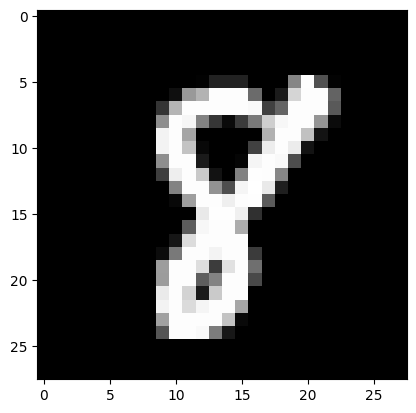

In [64]:
random_idx = np.random.randint(0, len(x_test))
x_to_predict = x_test[random_idx]
y_true = y_test[random_idx]
y_predicted = p._model.predict_digit(x_to_predict)

print(f"True: {y_true}; predicted: {y_predicted}")
show_digit(x_to_predict)

## Conclusion PSO

En relacion a los parametros de PSO notamos que:
- Es mejor mantener un `w < 1` para asegurar convergencia
- Si `c_global > c_local` converge muy rapido en las primeras iteraciones.

- Si la cantidad de particulas es mayor a 20 las iteraciones se vuelven muy lentas.
- Si la cantidad de particulas es menor a 10 las soluciones obtenidas no son buenas

- La solucion depende mucho de la aleatoridad. 
En la mayoria de los casos se queda en el optimo local donde
clasifica todos los datos con el mismo numero, aasegurando una accuracy del 0.1.

- Por lo anteriormente mencionado, `c_local` tiene que ser al menos 2 veces mas grandes que `c_global` para evitar quedarse en maximos locales

# Algoritmo genetico


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Flatten the images from 28x28 to 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
p1 = PSO(data, 1,1,1)
p1._model.model.fit(x_train, y_train, epochs=13, batch_size=32, validation_data=(x_test,y_test))

Epoch 1/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 766us/step - accuracy: 0.4235 - loss: 265441.3438 - val_accuracy: 0.7041 - val_loss: 3264.6304
Epoch 2/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.7409 - loss: 3590.1348 - val_accuracy: 0.8716 - val_loss: 1857.5936
Epoch 3/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.8007 - loss: 3223.8503 - val_accuracy: 0.8943 - val_loss: 1790.2242
Epoch 4/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.8292 - loss: 3218.8550 - val_accuracy: 0.8699 - val_loss: 2342.6853
Epoch 5/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.8472 - loss: 2979.6260 - val_accuracy: 0.8864 - val_loss: 2166.5659
Epoch 6/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.8637 - loss: 2604.1685 - val_accuracy: 0.8472 - val_loss: 3186.9583
Epoch 7/13
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accuracy: 0.8713 - loss: 2299.5608 - val_accuracy: 0.8983 - val_loss: 1614.7979
Epoch 8/13
1875/1875 ━━━━━━━━━━━

In [6]:
w1 = p1._model.get_weights_as_numpy()
p._model.set_custom_weights(w1)
p._best_weights = w1
w2 = p._model.get_weights_as_numpy()
np.array_equal(w1,w2)

True

In [7]:
r = np.random.randint(0, len(y_test))
x = x_test[r]
y = y_test[r]

y_predicted = p._model.predict_digit(x)
y_predicted_bp = p1._model.predict_digit(x)
print(f"Predicted idx={r} {y=} as {y_predicted=} {y_predicted_bp=}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted idx=5226 y=8 as y_predicted=8 y_predicted_bp=8


In [8]:
p.print_report()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 426us/step
[(7, 7), (2, 2), (1, 1), (0, 5), (4, 4), (1, 1), (4, 4), (9, 9), (5, 4), (9, 4), (0, 0), (6, 6), (9, 4), (0, 4), (1, 1), (5, 5), (9, 9), (7, 7), (3, 3), (4, 4), (9, 4), (6, 5), (6, 6), (5, 5), (4, 4), (0, 0), (7, 7), (4, 4), (0, 5), (1, 1), (3, 5), (1, 5), (3, 3), (4, 4), (7, 7), (2, 2), (7, 7), (1, 5), (2, 2), (1, 5), (1, 1), (7, 7), (4, 4), (2, 2), (3, 5), (5, 5), (1, 1), (2, 2), (4, 4), (4, 4), (6, 5), (3, 3), (5, 5), (5, 5), (6, 6), (0, 5), (4, 4), (1, 1), (9, 4), (5, 5), (7, 7), (8, 5), (9, 5), (3, 2), (7, 7), (4, 5), (6, 4), (4, 4), (3, 5), (0, 0), (7, 7), (0, 0), (2, 2), (9, 4), (1, 5), (7, 7), (3, 5), (2, 1), (9, 4), (7, 7), (7, 7), (6, 5), (2, 2), (7, 7), (8, 5), (4, 4), (7, 7), (3, 3), (6, 6), (1, 1), (3, 3), (6, 6), (9, 4), (3, 5), (1, 1), (4, 4), (1, 5), (7, 5), (6, 6), (9, 9), (6, 6), (0, 0), (5, 5), (4, 4), (9, 5), (9, 9), (2, 2), (1, 5), (9, 4), (4, 4), (8, 5), (7, 5), (3, 5), (9, 9), (7, 5), (4, 5), (4, 4), (4, 4), (9, 4), (2, 

In [9]:
p.train(epochs=10)

Iter 0 best fitness: 0.116. Global best 0.568
Iter 1 best fitness: 0.106. Global best 0.568
Iter 2 best fitness: 0.116. Global best 0.568
Iter 3 best fitness: 0.105. Global best 0.568
Iter 4 best fitness: 0.116. Global best 0.568
Iter 5 best fitness: 0.196. Global best 0.568
Iter 6 best fitness: 0.116. Global best 0.568
Iter 7 best fitness: 0.116. Global best 0.568
Iter 8 best fitness: 0.116. Global best 0.568
Iter 9 best fitness: 0.102. Global best 0.568


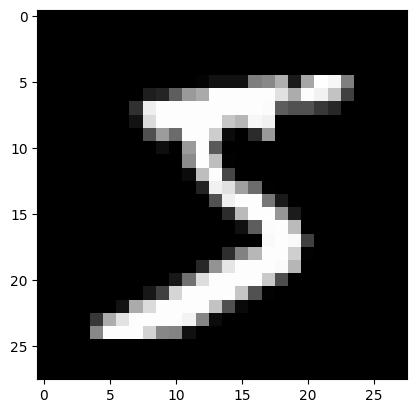